# Link Prediction mit GATv2

Dieses Notebook enthält **nur** Modell, Training und Auswertung. Die Daten kommen aus
`processed/philadelphia_split.pt`, erzeugt durch `data_prep.ipynb` (dort auch die Feature-Konfiguration).

In [26]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from gnn_pipeline import load_bundle, train_link_predictor, evaluate_link_predictor, plot_auc_history

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

bundle = load_bundle(device=device)   # processed/philadelphia_split.pt
data, train_data, val_data, test_data = bundle.data, bundle.train, bundle.val, bundle.test

in_channels = data.x.size(1)
edge_dim = data.edge_attr.size(1)

Device: cpu
Split geladen: processed\philadelphia_split.pt
Knoten: 13389, Kanten: 40003
Knotenfeatures (2): ['x', 'y']
Kantenfeatures (17): ['Capacity', 'Length', 'free_flow_time', 'Toll', 'capacity_ratio', 'delta_x', 'delta_y', 'capacity_is_placeholder', 'has_reciprocal', 'link_type_1', 'link_type_2', 'link_type_3', 'link_type_4', 'link_type_6', 'link_type_7', 'link_type_8', 'link_type_9']
train: msg-passing Kanten=32003, Label-Paare pos=32003 neg=64006
val: msg-passing Kanten=32003, Label-Paare pos=4000 neg=8000
test: msg-passing Kanten=36003, Label-Paare pos=4000 neg=8000
meta: {'seed': 42, 'val_ratio': 0.1, 'test_ratio': 0.1, 'neg_sampling_ratio': 2.0, 'node_features': ['coords']}


## Graph Attention Network v2 (GATv2) mit Kantenfeatures

GATv2 verbessert GAT, indem die Attention-Gewichte nach der Transformation der Nachbarfeatures
berechnet werden („dynamic attention“). Über `edge_dim` fließen die Kantenfeatures
(`Capacity`, `Length`, `Toll`, `free_flow_time`, …) direkt in die Attention-Berechnung ein.

**Architektur:** 3 × `GATv2Conv` (4, 4, 1 Heads) → Knoten-Embeddings → MLP-Decoder auf
`concat(src, dst)`. Der Decoder nutzt bewusst **keine** Features der Zielkante, damit die
Vorhersage nicht trivial wird.

In [27]:
import torch.nn as nn
from torch_geometric.nn import GATv2Conv

class GATv2LinkPredictor(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, edge_dim, heads=4, dropout=0.3):
        super().__init__()
        self.conv1 = GATv2Conv(in_channels, hidden_channels, edge_dim=edge_dim, heads=heads, concat=True)
        self.conv2 = GATv2Conv(hidden_channels * heads, hidden_channels, edge_dim=edge_dim, heads=heads, concat=True)
        self.conv3 = GATv2Conv(hidden_channels * heads, out_channels, edge_dim=edge_dim, heads=1, concat=False)
        self.dropout = nn.Dropout(dropout)
        self.decoder = nn.Sequential(
            nn.Linear(out_channels * 2, hidden_channels),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_channels, 1),
        )

    def forward(self, x, edge_index, edge_attr):
        x = self.dropout(self.conv1(x, edge_index, edge_attr).relu())
        x = self.dropout(self.conv2(x, edge_index, edge_attr).relu())
        return self.conv3(x, edge_index, edge_attr)

    def predict_link(self, node_embeddings, edge_label_index):
        src, dst = node_embeddings[edge_label_index[0]], node_embeddings[edge_label_index[1]]
        return self.decoder(torch.cat([src, dst], dim=1)).squeeze(-1)

In [32]:
MODEL_NAME = "GATv2"
HIDDEN, OUT = 128, 256
EPOCHS, LR, WEIGHT_DECAY = 300, 0.01, 0.0

torch.manual_seed(bundle.meta.get("seed", 42))
model = GATv2LinkPredictor(in_channels, HIDDEN, OUT, edge_dim).to(device)
print(model)
print(f"Parameter: {sum(p.numel() for p in model.parameters()):,}")

GATv2LinkPredictor(
  (conv1): GATv2Conv(2, 128, heads=4)
  (conv2): GATv2Conv(512, 128, heads=4)
  (conv3): GATv2Conv(512, 256, heads=1)
  (dropout): Dropout(p=0.3, inplace=False)
  (decoder): Sequential(
    (0): Linear(in_features=512, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=1, bias=True)
  )
)
Parameter: 881,153


In [33]:
history = train_link_predictor(
    model, train_data, val_data, test_data,
    epochs=EPOCHS, lr=LR, weight_decay=WEIGHT_DECAY, log_every=10,
)
plot_auc_history(history, title=f'{MODEL_NAME}: ROC-AUC über Epochen')
plt.show()

test_loss, test_auc = evaluate_link_predictor(model, train_data, test_data)
print(f"Finale Test-Loss {test_loss:.4f} | Test-ROC-AUC {test_auc:.4f}")

Epoch 001 | train loss 0.6969 | val AUC 0.5587 | test AUC 0.5578
Epoch 010 | train loss 0.6475 | val AUC 0.4878 | test AUC 0.4852
Epoch 020 | train loss 0.6409 | val AUC 0.4950 | test AUC 0.4944
Epoch 030 | train loss 0.6392 | val AUC 0.4948 | test AUC 0.5001
Epoch 040 | train loss 0.6380 | val AUC 0.5239 | test AUC 0.5304
Epoch 050 | train loss 0.6382 | val AUC 0.5179 | test AUC 0.5102
Epoch 060 | train loss 0.6380 | val AUC 0.4976 | test AUC 0.5050
Epoch 070 | train loss 0.6379 | val AUC 0.5234 | test AUC 0.5219
Epoch 080 | train loss 0.6376 | val AUC 0.4728 | test AUC 0.4759
Epoch 090 | train loss 0.6378 | val AUC 0.4489 | test AUC 0.4515
Epoch 100 | train loss 0.6379 | val AUC 0.4429 | test AUC 0.4465
Epoch 110 | train loss 0.6377 | val AUC 0.4552 | test AUC 0.4577
Epoch 120 | train loss 0.6377 | val AUC 0.4674 | test AUC 0.4726
Epoch 130 | train loss 0.6372 | val AUC 0.4573 | test AUC 0.4605
Epoch 140 | train loss 0.6375 | val AUC 0.4689 | test AUC 0.4695
Epoch 150 | train loss 0.

KeyboardInterrupt: 

## Visualisierung der Knoten-Embeddings

PCA der gelernten Embeddings auf 2 Dimensionen, eingefärbt nach Knotentyp (Zone / Kreuzung).

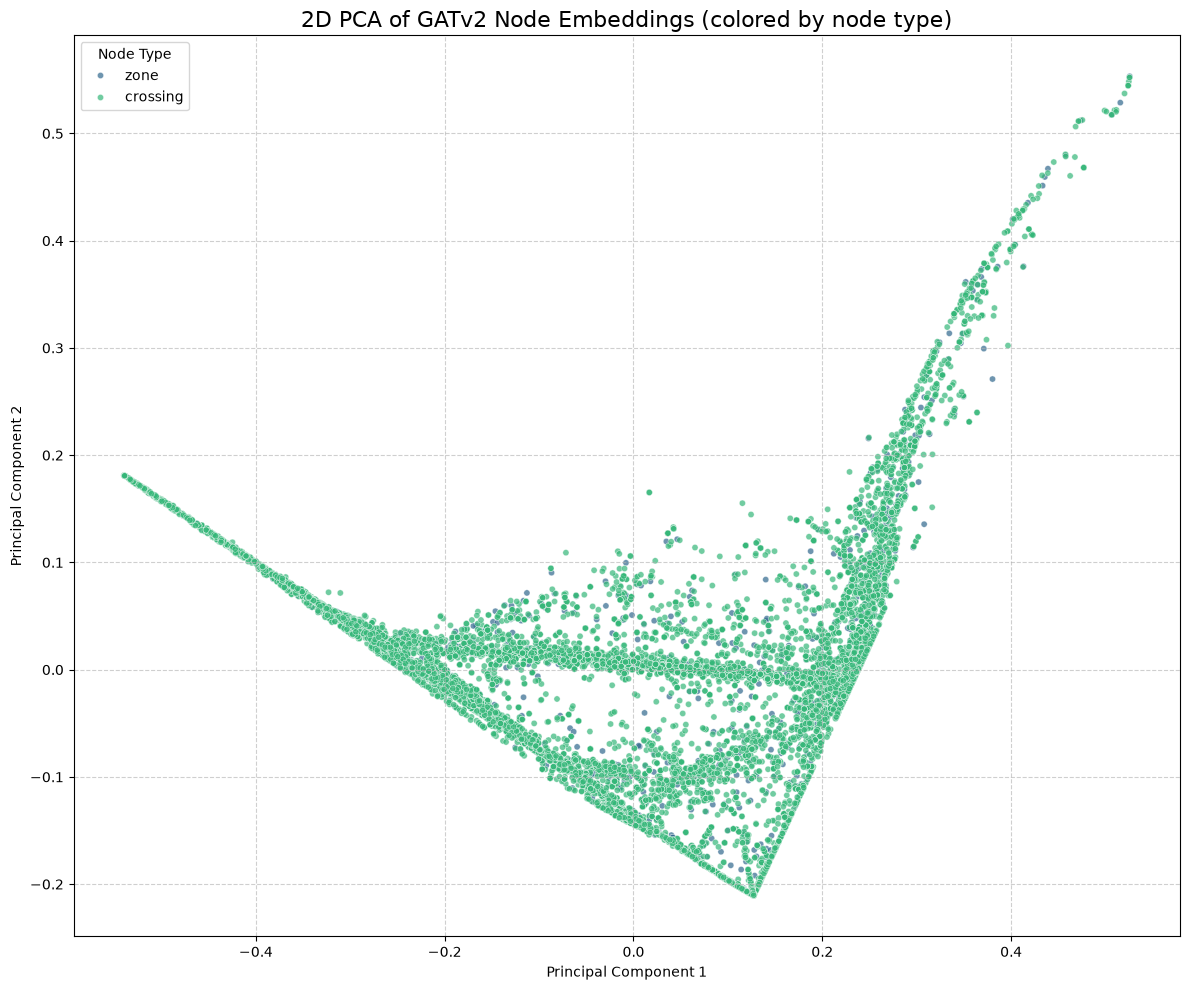

In [30]:
from sklearn.decomposition import PCA

model.eval()
with torch.no_grad():
    emb = model(data.x, data.edge_index, data.edge_attr).cpu().numpy()

emb_2d = PCA(n_components=2).fit_transform(emb)
plot_df = pd.DataFrame({'component_1': emb_2d[:, 0], 'component_2': emb_2d[:, 1], 'node_type': bundle.node_type})

plt.figure(figsize=(12, 10))
sns.scatterplot(data=plot_df, x='component_1', y='component_2', hue='node_type', palette='viridis', alpha=0.7, s=20)
plt.title(f'2D PCA of {MODEL_NAME} Node Embeddings (colored by node type)', size=16)
plt.xlabel('Principal Component 1'); plt.ylabel('Principal Component 2')
plt.legend(title='Node Type'); plt.grid(True, linestyle='--', alpha=0.6); plt.tight_layout()
plt.show()

## Feature-Analyse: Korrelation der Kantenfeatures mit dem Label

Pearson-Korrelation jedes Kantenfeatures (aus `edge_label_attr`) mit `edge_label` im Trainingssplit.
Hinweis: Negative Beispiele tragen zufällig gezogene Features, daher sind hohe Korrelationen hier nicht zu erwarten.

capacity_ratio             0.004903
link_type_2                0.003505
link_type_9                0.003117
capacity_is_placeholder    0.002226
Capacity                   0.002199
link_type_7                0.001366
link_type_3                0.000517
link_type_8                0.000463
has_reciprocal             0.000367
Toll                       0.000309
delta_y                   -0.000712
Length                    -0.000947
link_type_4               -0.000988
delta_x                   -0.001034
link_type_6               -0.001787
link_type_1               -0.002341
free_flow_time            -0.002536
Name: edge_label, dtype: float64


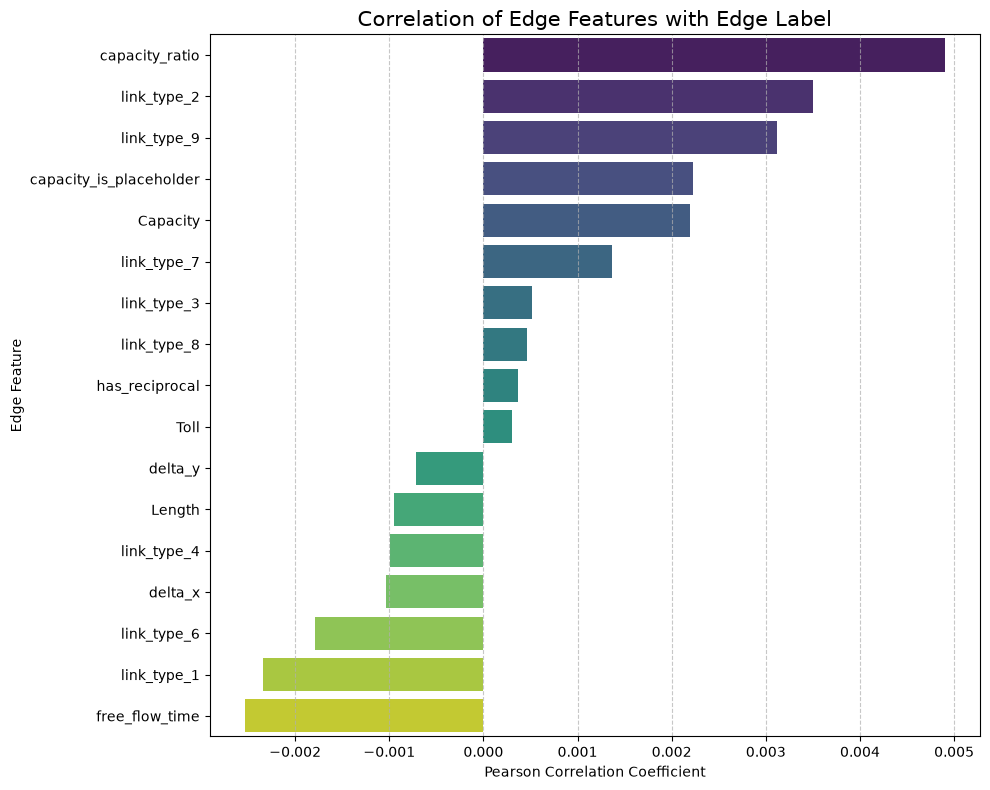

In [31]:
features_df = pd.DataFrame(train_data.edge_label_attr.cpu().numpy(), columns=bundle.edge_attr_columns)
features_df['edge_label'] = train_data.edge_label.cpu().numpy()
corr = features_df.corr()['edge_label'].drop('edge_label').sort_values(ascending=False)
print(corr)

plt.figure(figsize=(10, 8))
sns.barplot(x=corr.values, y=corr.index, hue=corr.index, palette='viridis', legend=False)
plt.title('Correlation of Edge Features with Edge Label', size=15)
plt.xlabel('Pearson Correlation Coefficient'); plt.ylabel('Edge Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7); plt.tight_layout()
plt.show()